In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

In [ ]:
df = pd.read_csv("/content/hotel_bookings.csv")


In [ ]:
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(14684, 32)


In [ ]:

print("\nFirst 5 Rows")
print(df.head())



First 5 Rows
          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0     2.0  ...    No Dep

In [ ]:
print("\nMissing Values")
print(df.isnull().sum())



Missing Values
hotel                                 0
is_canceled                           0
lead_time                             0
arrival_date_year                     0
arrival_date_month                    0
arrival_date_week_number              0
arrival_date_day_of_month             0
stays_in_weekend_nights               0
stays_in_week_nights                  0
adults                                1
children                              1
babies                                1
meal                                  1
country                             438
market_segment                        1
distribution_channel                  1
is_repeated_guest                     1
previous_cancellations                1
previous_bookings_not_canceled        1
reserved_room_type                    1
assigned_room_type                    1
booking_changes                       1
deposit_type                          1
agent                              2512
company                 

In [ ]:
df['children'] = df['children'].fillna(0)
df['country'] = df['country'].fillna('Unknown')
df['agent'] = df['agent'].fillna(0)
df['company'] = df['company'].fillna(0)


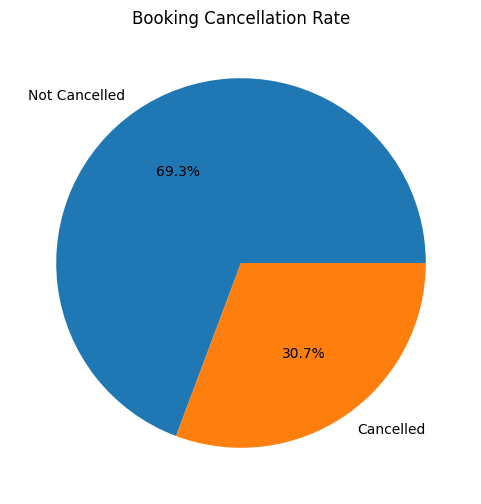

In [ ]:
plt.figure(figsize=(6,6))

df['is_canceled'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['Not Cancelled','Cancelled']
)

plt.title("Booking Cancellation Rate")
plt.ylabel("")
plt.show()

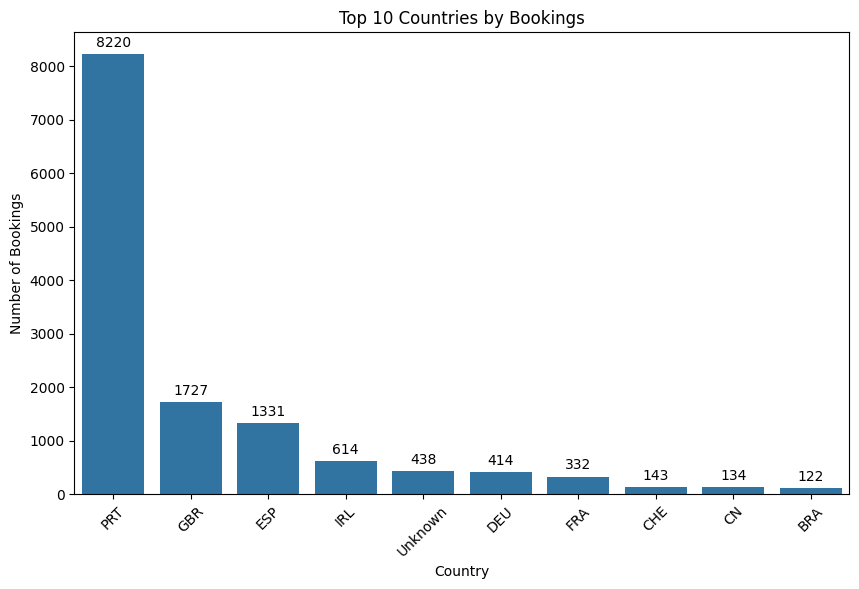

In [ ]:
plt.figure(figsize=(10,6))

top_country = df['country'].value_counts().head(10)

ax = sns.barplot(
    x=top_country.index,
    y=top_country.values
)

# Add values on bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%d',
        padding=3
    )

plt.title("Top 10 Countries by Bookings")
plt.xlabel("Country")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)

plt.show()

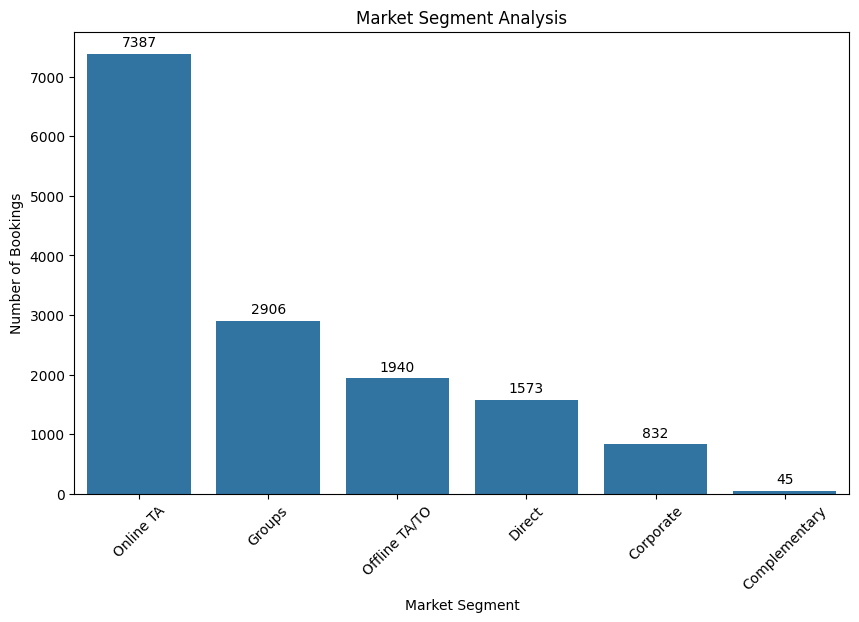

In [ ]:
plt.figure(figsize=(10,6))

ax = sns.countplot(
    data=df,
    x='market_segment',
    order=df['market_segment'].value_counts().index
)

# Add labels on bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%d',
        padding=3
    )

plt.title("Market Segment Analysis")
plt.xlabel("Market Segment")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)

plt.show()

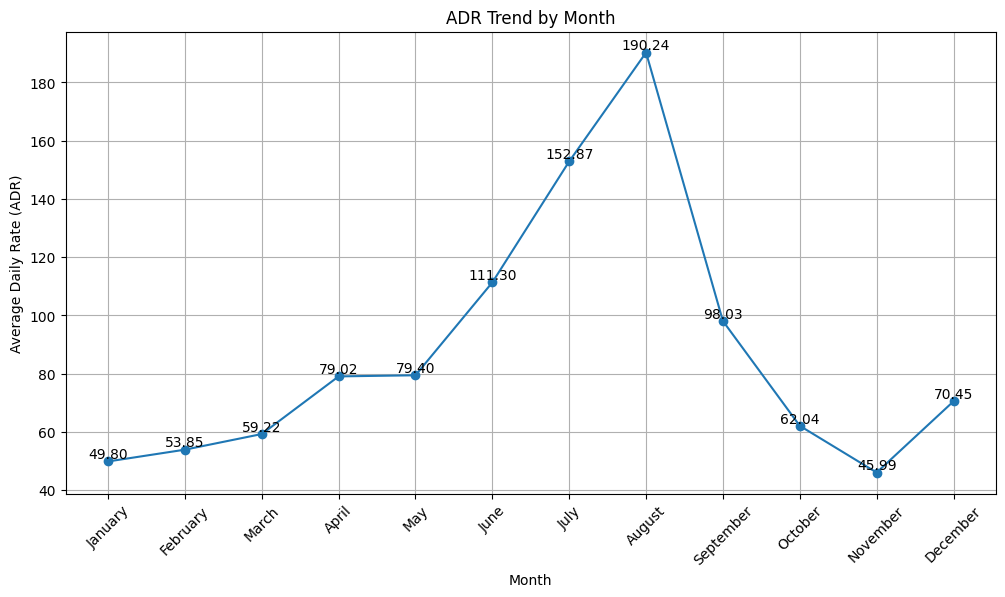

In [ ]:
month_order = [
'January','February','March','April',
'May','June','July','August',
'September','October','November','December'
]

monthly_adr = df.groupby(
    'arrival_date_month'
)['adr'].mean().reindex(month_order)

plt.figure(figsize=(12,6))

plt.plot(
    monthly_adr.index,
    monthly_adr.values,
    marker='o'
)

# Add value labels
for x, y in zip(monthly_adr.index, monthly_adr.values):
    plt.text(
        x,
        y,
        f'{y:.2f}',
        ha='center',
        va='bottom'
    )

plt.title("ADR Trend by Month")
plt.xlabel("Month")
plt.ylabel("Average Daily Rate (ADR)")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

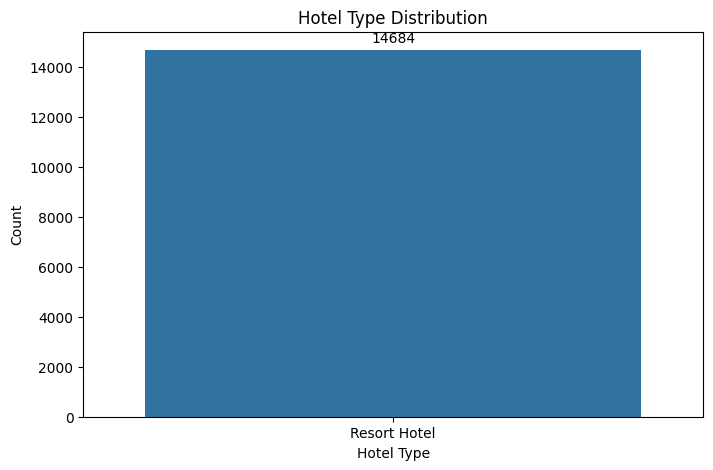

In [ ]:
 plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x='hotel'
)

# Add values on top of bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%d',      # integer format
        padding=3      # gap between bar and label
    )

plt.title("Hotel Type Distribution")
plt.xlabel("Hotel Type")
plt.ylabel("Count")

plt.show()

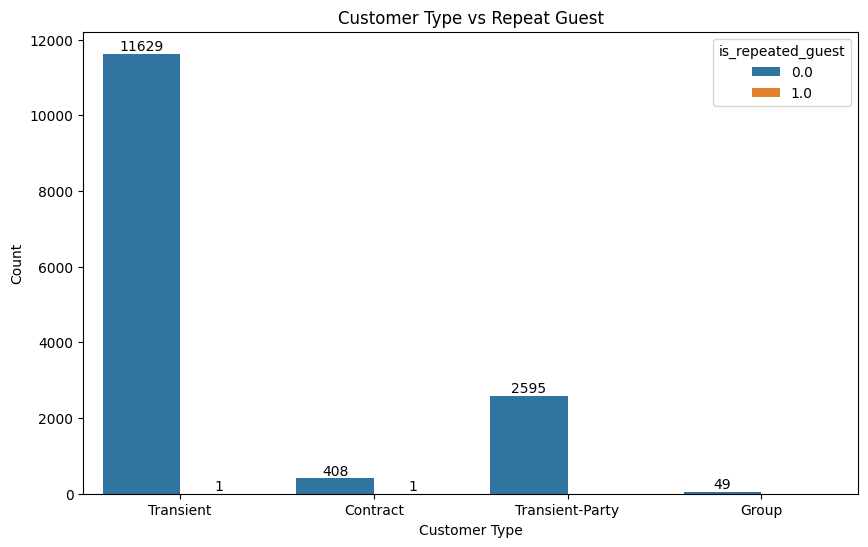

In [ ]:
plt.figure(figsize=(10,6))

ax = sns.countplot(
    data=df,
    x='customer_type',
    hue='is_repeated_guest'
)

# Add value labels
for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Type vs Repeat Guest")
plt.xlabel("Customer Type")
plt.ylabel("Count")

plt.show()

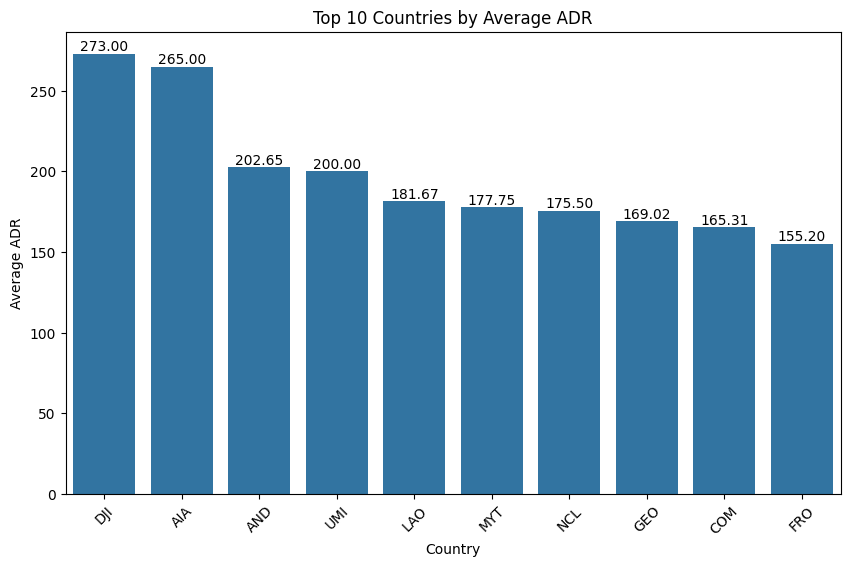

In [ ]:
country_adr = df.groupby(
    'country'
)['adr'].mean().sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=country_adr.index,
    y=country_adr.values
)

for i, v in enumerate(country_adr.values):
    ax.text(
        i,
        v,
        f'{v:.2f}',
        ha='center',
        va='bottom'
    )

plt.title("Top 10 Countries by Average ADR")
plt.xlabel("Country")
plt.ylabel("Average ADR")
plt.xticks(rotation=45)

plt.show()

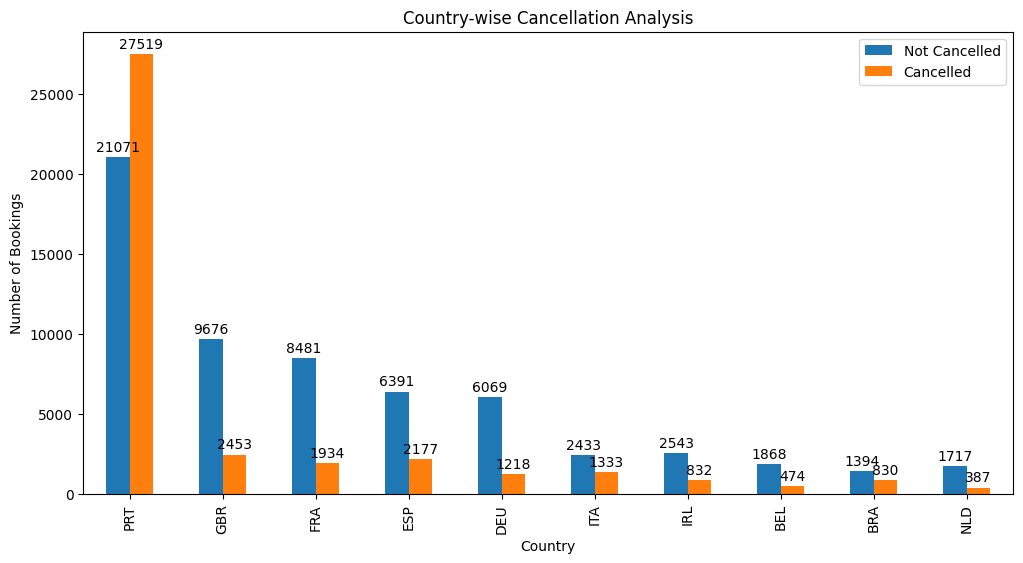

In [ ]:
country_cancel = pd.crosstab(
    df['country'],
    df['is_canceled']
)

top_country = df['country'].value_counts().head(10).index

country_cancel = country_cancel.loc[top_country]

ax = country_cancel.plot(
    kind='bar',
    figsize=(12,6)
)

# Add labels to both bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%d',
        padding=2
    )

plt.title("Country-wise Cancellation Analysis")
plt.xlabel("Country")
plt.ylabel("Number of Bookings")
plt.legend(['Not Cancelled','Cancelled'])

plt.show()